In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
modelRF = RandomForestRegressor()

In [2]:
data = pd.read_csv('Critical_Sales_Data.csv')
data = data.rename(columns= {"Date" : "datetime"})

In [3]:
data

,Invoice_ID,datetime,Customer_Name,Customer_ID,Region,Product,Category,Product_ID,Quantity,Unit_Price,Total_Amount
0,INV10000,01-01-2023 00:00,Arjun Desai,1428,Central,Mobile Phone,Electronics,PID147,1,544.48,544.48
1,INV10001,01-01-2023 01:00,Neha Rao,4162,West,Rice Cooker,Home Appliances,PID145,9,758.62,6827.58
2,INV10002,01-01-2023 02:00,Arjun Desai,3492,Central,T-Shirt,Clothing,PID113,3,1392.82,4178.46
3,INV10003,01-01-2023 03:00,Amit Shah,2256,West,T-Shirt,Clothing,PID127,7,1275.70,8929.90
4,INV10004,01-01-2023 04:00,Sneha Kulkarni,3910,Central,Microwave,Home Appliances,PID134,6,2059.04,12354.24
...,...,...,...,...,...,...,...,...,...,...,...
11995,INV21995,14-05-2024 19:00,Karan Patel,2689,East,LED TV,Electronics,PID131,6,864.00,5184.00
11996,INV21996,14-05-2024 20:00,Sneha Kulkarni,2864,East,Jeans,Clothing,PID107,7,1892.27,13245.89
11997,INV21997,14-05-2024 21:00,Amit Shah,2320,East,Mobile Phone,Electronics,PID147,5,1623.56,8117.80
11998,INV21998,14-05-2024 22:00,Amit Shah,2738,West,Rice Cooker,Home Appliances,PID120,1,166.44,166.44


In [4]:
data = data.drop(columns=['Invoice_ID' , 'Customer_Name' , 'Product_ID' , 'Category' , 'Product' , 'Customer_ID' , 'Quantity' ])

In [5]:
data

,datetime,Region,Unit_Price,Total_Amount
0,01-01-2023 00:00,Central,544.48,544.48
1,01-01-2023 01:00,West,758.62,6827.58
2,01-01-2023 02:00,Central,1392.82,4178.46
3,01-01-2023 03:00,West,1275.70,8929.90
4,01-01-2023 04:00,Central,2059.04,12354.24
...,...,...,...,...
11995,14-05-2024 19:00,East,864.00,5184.00
11996,14-05-2024 20:00,East,1892.27,13245.89
11997,14-05-2024 21:00,East,1623.56,8117.80
11998,14-05-2024 22:00,West,166.44,166.44


In [6]:
data['datetime'] = pd.to_datetime(data['datetime'] , format = '%d-%m-%Y %H:%M')

In [7]:
data['Region'].unique()

array(['Central', 'West', 'East', 'North', 'South'], dtype=object)

## Extracting Features ##

In [8]:
data['Date'] = data['datetime'].dt.day
data['Month'] = data['datetime'].dt.month
data['Year'] = data['datetime'].dt.year
data['Hour'] = data['datetime'].dt.hour

In [9]:
data = data.drop('datetime' , axis=1)

In [10]:
data_encode = pd.get_dummies(data, columns=['Region'])
data_encode

,Unit_Price,Total_Amount,Date,Month,Year,Hour,Region_Central,Region_East,Region_North,Region_South,Region_West
0,544.48,544.48,1,1,2023,0,True,False,False,False,False
1,758.62,6827.58,1,1,2023,1,False,False,False,False,True
2,1392.82,4178.46,1,1,2023,2,True,False,False,False,False
3,1275.70,8929.90,1,1,2023,3,False,False,False,False,True
4,2059.04,12354.24,1,1,2023,4,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
11995,864.00,5184.00,14,5,2024,19,False,True,False,False,False
11996,1892.27,13245.89,14,5,2024,20,False,True,False,False,False
11997,1623.56,8117.80,14,5,2024,21,False,True,False,False,False
11998,166.44,166.44,14,5,2024,22,False,False,False,False,True


In [11]:
x = data_encode.drop('Total_Amount' , axis=1)
y = data_encode['Total_Amount']

In [12]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state=42)
y_train

9182      4378.32
11091     2193.12
6428      2968.38
288       2025.12
2626      1955.22
           ...   
11964     7720.23
5191      2566.25
5390      3901.14
860      16571.07
7270      5000.52
Name: Total_Amount, Length: 9600, dtype: float64

## Random Forest Traning ##

In [13]:
modelRF.fit(x_train , y_train)

RandomForestRegressor()

In [14]:
predictionRF = modelRF.predict(x_test)
predictionRF

array([ 8148.1259, 11224.9641,  4371.9677, ...,  9286.3102,  9875.8864,
        2556.7062], shape=(2400,))

In [15]:
y_test_indx_reset = y_test.reset_index(drop=True)
df = pd.DataFrame({'Prediction' : predictionRF})
y_test = y_test.reset_index()
df['Actual'] = y_test_indx_reset

In [16]:
x_test

,Unit_Price,Date,Month,Year,Hour,Region_Central,Region_East,Region_North,Region_South,Region_West
1935,1821.60,22,3,2023,15,True,False,False,False,False
6494,2005.22,28,9,2023,14,True,False,False,False,False
1720,964.06,13,3,2023,16,False,True,False,False,False
9120,1406.07,16,1,2024,0,False,True,False,False,False
360,822.40,16,1,2023,0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
1195,522.60,19,2,2023,19,False,False,False,False,True
11877,975.71,9,5,2024,21,False,False,False,False,True
5421,1822.83,14,8,2023,21,False,False,False,False,True
3855,1737.27,10,6,2023,15,False,False,True,False,False


In [17]:
score = modelRF.score(x_test , y_test.drop('index' , axis=1))
score

0.39334159029312543

<Axes: xlabel='Actual', ylabel='Prediction'>

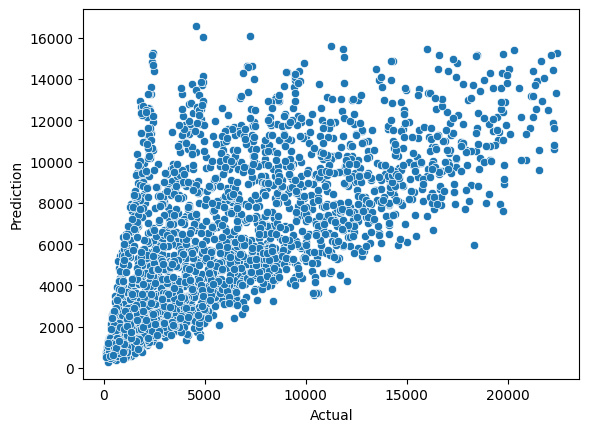

In [18]:
sns.scatterplot(data = df , x = 'Actual' , y = 'Prediction', alpha = 1)

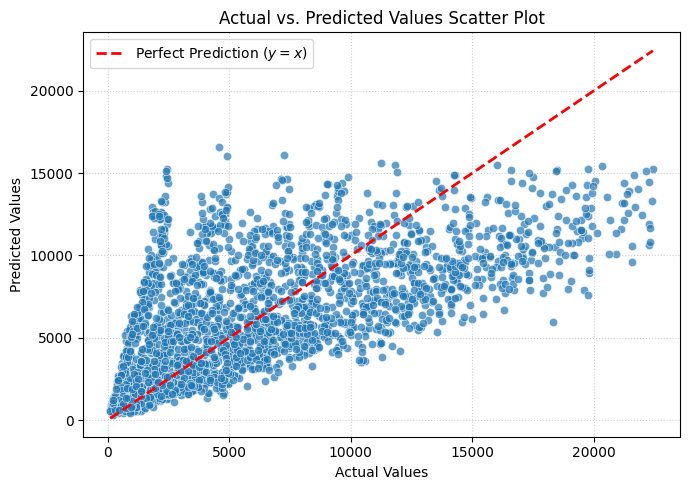

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Actual', y='Prediction', data=df, alpha=0.7)

# Add the perfect prediction line (y=x)
min_val = min(df['Actual'].min(), df['Prediction'].min())
max_val = max(df['Actual'].max(), df['Prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction ($y=x$)')

plt.title('Actual vs. Predicted Values Scatter Plot')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
data_encode

,Unit_Price,Total_Amount,Date,Month,Year,Hour,Region_Central,Region_East,Region_North,Region_South,Region_West
0,544.48,544.48,1,1,2023,0,True,False,False,False,False
1,758.62,6827.58,1,1,2023,1,False,False,False,False,True
2,1392.82,4178.46,1,1,2023,2,True,False,False,False,False
3,1275.70,8929.90,1,1,2023,3,False,False,False,False,True
4,2059.04,12354.24,1,1,2023,4,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
11995,864.00,5184.00,14,5,2024,19,False,True,False,False,False
11996,1892.27,13245.89,14,5,2024,20,False,True,False,False,False
11997,1623.56,8117.80,14,5,2024,21,False,True,False,False,False
11998,166.44,166.44,14,5,2024,22,False,False,False,False,True


In [21]:
modelRF.predict([[1406.07 , 1 , 6 , 2025 , 10 , False	,True,	False	, False  , 	False]])

C:\Users\Nakesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([6772.5838])